# My Custom Breakout RL

This notebook is self-contained: I have designed this so running the cells 
top to bottom writes out the project's `.py` files into your notebook's 
working directory, installs the dependencies, trains a PPO agent to play my 
custom Breakout clone, and lets you watch it play **inline** 
(no display/window needed, this should work on remote or cloud notebooks like Colab too).

**How this works:**
- `breakout_env.py`, `train.py`, `watch.py`, `plot_progress.py` are written
  to disk with `%%writefile`, then *imported or run as scripts*. This keeps
  `train.py`'s command-line arguments working normally and avoids issues
  with re-running class/`gym.register()` definitions directly in cells.
- The Training is launched with `!python train.py ...` (a shell command run
  from the notebook) rather than by pasting the training loop into a cell 
  this keeps stdout progress printing live and avoids notebook/multiprocessing
  quirks.
- Watching the agent play uses an **inline HTML5 video** helper
  (`record_episode` + `show_inline`) instead of the live pygame window,
  since most Jupyter setups (especially cloud ones) have no display for
  pygame to open a window on.


In [1]:
# 1. Install dependencies
!pip install -q gymnasium stable-baselines3 pygame numpy pandas matplotlib torch tqdm rich

## 2. Write the project files to disk


In [2]:
%%writefile breakout_env.py
"""
A custom Breakout clone implemented as a Gymnasium environment.

The game logic (ball/paddle/brick physics) is pure numpy and has no
dependency on pygame, so training can run headless and fast. pygame is
only imported/used when render_mode="human" (i.e. when you want to watch).
"""
import numpy as np
import gymnasium as gym
from gymnasium import spaces

# ---- Game constants (tweak these to change the "rules" of your Breakout) ----
FIELD_W, FIELD_H = 600, 400
PADDLE_W, PADDLE_H = 70, 12
PADDLE_Y = FIELD_H - 30
PADDLE_SPEED = 8.0

BALL_RADIUS = 6
BALL_SPEED = 6.0

BRICK_ROWS, BRICK_COLS = 5, 8
BRICK_W = FIELD_W / BRICK_COLS
BRICK_H = 18
BRICK_TOP_MARGIN = 40
BRICK_GAP = 2

START_LIVES = 3
MAX_STEPS = 3000


class BreakoutGame:
    """Pure game logic. No rendering, no gym API — just physics + state."""

    def __init__(self, rng: np.random.Generator):
        self.rng = rng
        self.reset()

    def reset(self):
        self.paddle_x = FIELD_W / 2 - PADDLE_W / 2
        self._launch_ball()
        self.bricks = np.ones((BRICK_ROWS, BRICK_COLS), dtype=np.float32)
        self.lives = START_LIVES
        self.score = 0
        self.steps = 0

    def _launch_ball(self):
        self.ball_x = FIELD_W / 2
        self.ball_y = PADDLE_Y - BALL_RADIUS - 2
        angle = self.rng.uniform(-0.6, 0.6)  # radians off straight-up
        self.ball_vx = BALL_SPEED * np.sin(angle)
        self.ball_vy = -BALL_SPEED * np.cos(angle)

    def brick_rect(self, row, col):
        x = col * BRICK_W + BRICK_GAP / 2
        y = BRICK_TOP_MARGIN + row * BRICK_H + BRICK_GAP / 2
        return x, y, BRICK_W - BRICK_GAP, BRICK_H - BRICK_GAP

    def step(self, action: int):
        """action: 0 = stay, 1 = left, 2 = right. Returns (reward, terminated)."""
        self.steps += 1
        reward = 0.0
        terminated = False

        # --- paddle movement ---
        if action == 1:
            self.paddle_x -= PADDLE_SPEED
        elif action == 2:
            self.paddle_x += PADDLE_SPEED
        self.paddle_x = np.clip(self.paddle_x, 0, FIELD_W - PADDLE_W)

        # --- ball movement ---
        self.ball_x += self.ball_vx
        self.ball_y += self.ball_vy

        # walls
        if self.ball_x <= BALL_RADIUS:
            self.ball_x = BALL_RADIUS
            self.ball_vx *= -1
        elif self.ball_x >= FIELD_W - BALL_RADIUS:
            self.ball_x = FIELD_W - BALL_RADIUS
            self.ball_vx *= -1
        if self.ball_y <= BALL_RADIUS:
            self.ball_y = BALL_RADIUS
            self.ball_vy *= -1

        # paddle collision
        if (self.ball_vy > 0
                and PADDLE_Y <= self.ball_y + BALL_RADIUS <= PADDLE_Y + PADDLE_H
                and self.paddle_x <= self.ball_x <= self.paddle_x + PADDLE_W):
            hit_pos = (self.ball_x - (self.paddle_x + PADDLE_W / 2)) / (PADDLE_W / 2)
            angle = hit_pos * 1.0  # steer angle based on where it hit the paddle
            speed = np.hypot(self.ball_vx, self.ball_vy)
            self.ball_vx = speed * np.sin(angle)
            self.ball_vy = -abs(speed * np.cos(angle))
            self.ball_y = PADDLE_Y - BALL_RADIUS
            reward += 0.1  # small shaping reward for keeping the ball alive

        # brick collisions
        row = int((self.ball_y - BRICK_TOP_MARGIN) // BRICK_H)
        col = int(self.ball_x // BRICK_W)
        if 0 <= row < BRICK_ROWS and 0 <= col < BRICK_COLS and self.bricks[row, col] > 0:
            bx, by, bw, bh = self.brick_rect(row, col)
            if bx <= self.ball_x <= bx + bw and by <= self.ball_y <= by + bh:
                self.bricks[row, col] = 0
                self.ball_vy *= -1
                reward += 1.0
                self.score += 1

        # ball fell below paddle -> lose a life
        if self.ball_y > FIELD_H:
            self.lives -= 1
            reward -= 1.0
            if self.lives <= 0:
                terminated = True
            else:
                self._launch_ball()

        # cleared all bricks -> win
        if self.bricks.sum() == 0:
            reward += 10.0
            terminated = True

        if self.steps >= MAX_STEPS:
            terminated = True  # env wrapper will treat as truncation

        return reward, terminated

    def get_obs(self):
        obs = np.concatenate([
            [self.paddle_x / FIELD_W],
            [self.ball_x / FIELD_W],
            [self.ball_y / FIELD_H],
            [self.ball_vx / BALL_SPEED],
            [self.ball_vy / BALL_SPEED],
            [self.lives / START_LIVES],
            self.bricks.flatten(),
        ]).astype(np.float32)
        return obs


class BreakoutEnv(gym.Env):
    metadata = {"render_modes": ["human", "rgb_array"], "render_fps": 60}

    def __init__(self, render_mode=None):
        super().__init__()
        self.render_mode = render_mode
        obs_dim = 6 + BRICK_ROWS * BRICK_COLS
        self.observation_space = spaces.Box(low=-1.5, high=1.5, shape=(obs_dim,), dtype=np.float32)
        self.action_space = spaces.Discrete(3)  # 0 stay, 1 left, 2 right
        self._rng = np.random.default_rng()
        self.game = BreakoutGame(self._rng)
        self._screen = None
        self._clock = None
        self._font = None

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        if seed is not None:
            self._rng = np.random.default_rng(seed)
        self.game = BreakoutGame(self._rng)
        obs = self.game.get_obs()
        info = {"score": self.game.score, "lives": self.game.lives}
        if self.render_mode == "human":
            self._render_frame()
        return obs, info

    def step(self, action):
        reward, terminated = self.game.step(int(action))
        truncated = self.game.steps >= MAX_STEPS and not terminated
        obs = self.game.get_obs()
        info = {"score": self.game.score, "lives": self.game.lives}
        if self.render_mode == "human":
            self._render_frame()
        return obs, reward, terminated, truncated, info

    def render(self):
        """Draws the current frame. In 'human' mode this also pushes it to a
        real OS window (only works when a display is available). In
        'rgb_array' mode it draws to an off-screen surface (no display
        needed at all — safe for remote/cloud Jupyter) and returns a
        (H, W, 3) uint8 numpy array you can show inline with imshow."""
        return self._render_frame()

    def _render_frame(self):
        import os
        os.environ.setdefault("SDL_AUDIODRIVER", "dummy")
        import pygame
        if not pygame.get_init():
            pygame.display.init()
            pygame.font.init()

        if self.render_mode == "human":
            if self._screen is None:
                pygame.display.set_caption("Custom Breakout - RL Agent")
                self._screen = pygame.display.set_mode((FIELD_W, FIELD_H))
                self._clock = pygame.time.Clock()
            for event in pygame.event.get():
                if event.type == pygame.QUIT:
                    pygame.quit()
                    raise SystemExit
            surface = self._screen
        else:
            # Off-screen surface — no display/window required at all.
            surface = pygame.Surface((FIELD_W, FIELD_H))

        if self._font is None:
            self._font = pygame.font.SysFont("arial", 18)

        surface.fill((15, 15, 25))
        g = self.game
        # paddle
        pygame.draw.rect(surface, (240, 240, 240),
                          (g.paddle_x, PADDLE_Y, PADDLE_W, PADDLE_H), border_radius=3)
        # ball
        pygame.draw.circle(surface, (255, 200, 60), (int(g.ball_x), int(g.ball_y)), BALL_RADIUS)
        # bricks
        colors = [(220, 70, 70), (230, 140, 60), (230, 210, 60), (110, 200, 90), (80, 150, 230)]
        for row in range(BRICK_ROWS):
            for col in range(BRICK_COLS):
                if g.bricks[row, col] > 0:
                    x, y, w, h = g.brick_rect(row, col)
                    pygame.draw.rect(surface, colors[row % len(colors)], (x, y, w, h), border_radius=2)
        # HUD
        hud = self._font.render(f"Score: {g.score}   Lives: {g.lives}", True, (255, 255, 255))
        surface.blit(hud, (8, 8))

        if self.render_mode == "human":
            pygame.display.flip()
            self._clock.tick(self.metadata["render_fps"])
            return None
        else:
            # (W, H, 3) -> transpose to the (H, W, 3) that imshow/gif writers expect
            arr = pygame.surfarray.array3d(surface)
            return np.transpose(arr, (1, 0, 2))

    def close(self):
        if self._screen is not None:
            import pygame
            pygame.quit()
            self._screen = None
            self._font = None


# Register with gymnasium so it can be created via gym.make if desired
gym.register(id="CustomBreakout-v0", entry_point="breakout_env:BreakoutEnv")


Writing breakout_env.py


In [3]:
%%writefile train.py
"""
Train an RL agent (PPO) to play our custom Breakout.

Usage:
    python train.py --timesteps 500000
    python train.py --timesteps 2000000 --n-envs 8

Progress (episode reward/length over time) is logged to ./logs/monitor*.csv
via stable-baselines3's Monitor wrapper. Model checkpoints are saved to
./models/ periodically, and the best-performing model is saved separately.

While training, run `python plot_progress.py` in another terminal any time
to see a learning curve of how the agent is improving.
"""
import argparse
import os

from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.callbacks import CheckpointCallback, EvalCallback
from stable_baselines3.common.monitor import Monitor

from breakout_env import BreakoutEnv

LOG_DIR = "./logs"
MODEL_DIR = "./models"


def make_env():
    def _init():
        env = BreakoutEnv(render_mode=None)
        return env
    return _init


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--timesteps", type=int, default=500_000,
                         help="Total training timesteps")
    parser.add_argument("--n-envs", type=int, default=8,
                         help="Number of parallel environments")
    parser.add_argument("--resume", type=str, default=None,
                         help="Path to a saved model .zip to resume training from")
    args = parser.parse_args()

    os.makedirs(LOG_DIR, exist_ok=True)
    os.makedirs(MODEL_DIR, exist_ok=True)

    # Vectorized training envs (headless, fast)
    vec_env = make_vec_env(make_env(), n_envs=args.n_envs, monitor_dir=LOG_DIR)

    # Separate env used only for periodic evaluation (also logged, for the best-model tracker)
    eval_env = Monitor(BreakoutEnv(render_mode=None), filename=os.path.join(LOG_DIR, "eval"))

    if args.resume:
        print(f"Resuming from {args.resume}")
        model = PPO.load(args.resume, env=vec_env)
    else:
        model = PPO(
            "MlpPolicy",
            vec_env,
            verbose=1,
            learning_rate=3e-4,
            n_steps=512,
            batch_size=256,
            gamma=0.99,
            ent_coef=0.01,
        )

    checkpoint_cb = CheckpointCallback(
        save_freq=max(50_000 // args.n_envs, 1),
        save_path=MODEL_DIR,
        name_prefix="breakout_ppo",
    )
    eval_cb = EvalCallback(
        eval_env,
        best_model_save_path=MODEL_DIR,
        log_path=LOG_DIR,
        eval_freq=max(20_000 // args.n_envs, 1),
        n_eval_episodes=5,
        deterministic=True,
    )

    print(f"Training for {args.timesteps} timesteps across {args.n_envs} parallel envs...")
    model.learn(total_timesteps=args.timesteps, callback=[checkpoint_cb, eval_cb], progress_bar=True)

    final_path = os.path.join(MODEL_DIR, "breakout_final")
    model.save(final_path)
    print(f"Done. Final model saved to {final_path}.zip")
    print(f"Best model (highest eval score) saved to {MODEL_DIR}/best_model.zip")
    print("Run `python watch.py` to see it play, or `python plot_progress.py` to see the learning curve.")


if __name__ == "__main__":
    main()


Writing train.py


In [4]:
%%writefile watch.py
"""
Watch a trained agent play Breakout.

Two ways to use this:

1. From a terminal, with a real display attached — opens a live pygame
   window:
       python watch.py                          # uses models/best_model.zip
       python watch.py --model models/breakout_final.zip

2. From a Jupyter notebook (including remote/cloud notebooks with no
   display, e.g. Colab) — import `record_episode` and `show_inline` to
   capture an episode as frames and play it back as an inline HTML5 video.
   See the "Watch it play" cell in breakout_rl.ipynb for a worked example.
"""
import argparse
import time

from stable_baselines3 import PPO
from breakout_env import BreakoutEnv


def record_episode(model, deterministic=True):
    """Run one episode with render_mode='rgb_array' (no display needed) and
    return (frames, score) where frames is a list of (H, W, 3) uint8 arrays."""
    env = BreakoutEnv(render_mode="rgb_array")
    obs, info = env.reset()
    frames = [env.render()]
    done = False
    while not done:
        action, _ = model.predict(obs, deterministic=deterministic)
        obs, reward, terminated, truncated, info = env.step(action)
        frames.append(env.render())
        done = terminated or truncated
    env.close()
    return frames, info["score"]


def show_inline(frames, fps=30):
    """Turn a list of frames into an inline HTML5 video for a notebook cell.
    Call this as the LAST line of a cell so it renders, e.g.:
        frames, score = record_episode(model)
        show_inline(frames)
    """
    import matplotlib.pyplot as plt
    from matplotlib import animation
    from IPython.display import HTML

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.axis("off")
    im = ax.imshow(frames[0])

    def update(i):
        im.set_data(frames[i])
        return [im]

    anim = animation.FuncAnimation(fig, update, frames=len(frames),
                                    interval=1000 / fps, blit=True)
    plt.close(fig)  # don't also show the static final frame
    return HTML(anim.to_jshtml())


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--model", type=str, default="./models/best_model.zip")
    parser.add_argument("--episodes", type=int, default=5)
    parser.add_argument("--deterministic", action="store_true", default=True)
    args = parser.parse_args()

    model = PPO.load(args.model)
    env = BreakoutEnv(render_mode="human")

    for ep in range(args.episodes):
        obs, info = env.reset()
        done = False
        ep_reward = 0.0
        while not done:
            action, _ = model.predict(obs, deterministic=args.deterministic)
            obs, reward, terminated, truncated, info = env.step(action)
            ep_reward += reward
            done = terminated or truncated
            env.render()
        print(f"Episode {ep + 1}: score={info['score']} reward={ep_reward:.1f}")
        time.sleep(0.5)

    env.close()


if __name__ == "__main__":
    main()


Writing watch.py


In [5]:
%%writefile plot_progress.py
"""
Plot the agent's learning curve (episode reward over time) from the
Monitor logs written during training.

Usage:
    python plot_progress.py
    python plot_progress.py --logdir ./logs --window 50
"""
import argparse
import glob
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def load_monitor_csvs(logdir):
    files = glob.glob(os.path.join(logdir, "*.monitor.csv"))
    if not files:
        raise FileNotFoundError(
            f"No monitor CSV files found in {logdir}. Run train.py first."
        )
    frames = []
    for f in files:
        df = pd.read_csv(f, skiprows=1)  # first row is a JSON header comment
        df["source"] = os.path.basename(f)
        frames.append(df)
    all_df = pd.concat(frames, ignore_index=True)
    all_df = all_df.sort_values("t").reset_index(drop=True)
    return all_df


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--logdir", type=str, default="./logs")
    parser.add_argument("--window", type=int, default=50, help="Rolling average window (episodes)")
    parser.add_argument("--out", type=str, default="learning_curve.png")
    args = parser.parse_args()

    df = load_monitor_csvs(args.logdir)
    df["episode"] = np.arange(1, len(df) + 1)
    df["reward_smooth"] = df["r"].rolling(args.window, min_periods=1).mean()

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    axes[0].plot(df["episode"], df["r"], alpha=0.25, color="tab:blue", label="episode reward")
    axes[0].plot(df["episode"], df["reward_smooth"], color="tab:blue", linewidth=2,
                 label=f"{args.window}-episode moving avg")
    axes[0].set_xlabel("Episode")
    axes[0].set_ylabel("Reward")
    axes[0].set_title("Reward per episode")
    axes[0].legend()

    df["len_smooth"] = df["l"].rolling(args.window, min_periods=1).mean()
    axes[1].plot(df["episode"], df["l"], alpha=0.25, color="tab:green")
    axes[1].plot(df["episode"], df["len_smooth"], color="tab:green", linewidth=2,
                 label=f"{args.window}-episode moving avg")
    axes[1].set_xlabel("Episode")
    axes[1].set_ylabel("Steps survived")
    axes[1].set_title("Episode length (how long it survives)")
    axes[1].legend()

    fig.suptitle("Breakout Agent Learning Progress")
    fig.tight_layout()
    fig.savefig(args.out, dpi=150)
    print(f"Saved plot to {args.out}")
    print(f"Total episodes logged: {len(df)}")
    print(f"Most recent {args.window}-episode avg reward: {df['reward_smooth'].iloc[-1]:.2f}")


if __name__ == "__main__":
    main()


Writing plot_progress.py


## 3. Sanity checking my environment

Quick test. random actions, no rendering, this is just to confirm everything imports and runs before i spend time training.

In [6]:
from breakout_env import BreakoutEnv

env = BreakoutEnv()
obs, info = env.reset(seed=0)
print("Observation shape:", obs.shape, "| Action space:", env.action_space)

total_reward = 0
for _ in range(500):
    obs, r, terminated, truncated, info = env.step(env.action_space.sample())
    total_reward += r
    if terminated or truncated:
        obs, info = env.reset()
print("Ran 500 random steps fine. Total reward:", round(total_reward, 2))

Observation shape: (46,) | Action space: Discrete(3)
Ran 500 random steps fine. Total reward: 0.0


## 4. Train the agent to play

Here im `train.py` as a script (via `!python`), which is what keeps its
`argparse` flags working normally in a notebook. Progress prints live below
the cell, watch `ep_rew_mean` climb over time.

(If you try to run this on your machine, try to experiment with these parameters, ive included some defaults)Start small to make sure it works end to end, then scale up:
- `--timesteps 500000` is a reasonable first real run (a few minutes on CPU).
- Increase `--n-envs` if you have more CPU cores, to train faster in wall-clock time.
- Re-run with `--resume models/breakout_final.zip` to keep training an existing model — this is the easiest way to train in stages and watch it improve between stages.

In [7]:
!python train.py --timesteps 500000 --n-envs 8

Using cpu device
Training for 500000 timesteps across 8 parallel envs...

   0% ------------------------------- 0/500,000  [ 0:00:00 < -:--:-- , ? it/s ]
   0% ----------------------------- 536/500,000  [ 0:00:00 < -:--:-- , ? it/s ]
   0% ----------------------- 1,184/500,000  [ 0:00:00 < 0:01:25 , 5,891 it/s ]
   0% ----------------------- 1,848/500,000  [ 0:00:00 < 0:01:18 , 6,431 it/s ]
   1% ----------------------- 2,528/500,000  [ 0:00:00 < 0:01:19 , 6,364 it/s ]
   1% ----------------------- 3,176/500,000  [ 0:00:00 < 0:01:17 , 6,486 it/s ]
   1% ----------------------- 3,824/500,000  [ 0:00:00 < 0:01:18 , 6,372 it/s ]
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 346      |
|    ep_rew_mean     | 0.938    |
| time/              |          |
|    fps             | 6154     |
|    iterations      | 1        |
|    time_elapsed    | 0        |
|    total_timesteps | 4096     |
---------------------------------
   1% --------------------

## 5. Plotting the learning curve

Here im reading the training logs and showing reward-per-episode and survival-time-per-episode, so you can see the improvement trend rather than noisy single episodes.

Saved plot to learning_curve.png
Total episodes logged: 1647
Most recent 50-episode avg reward: 0.85


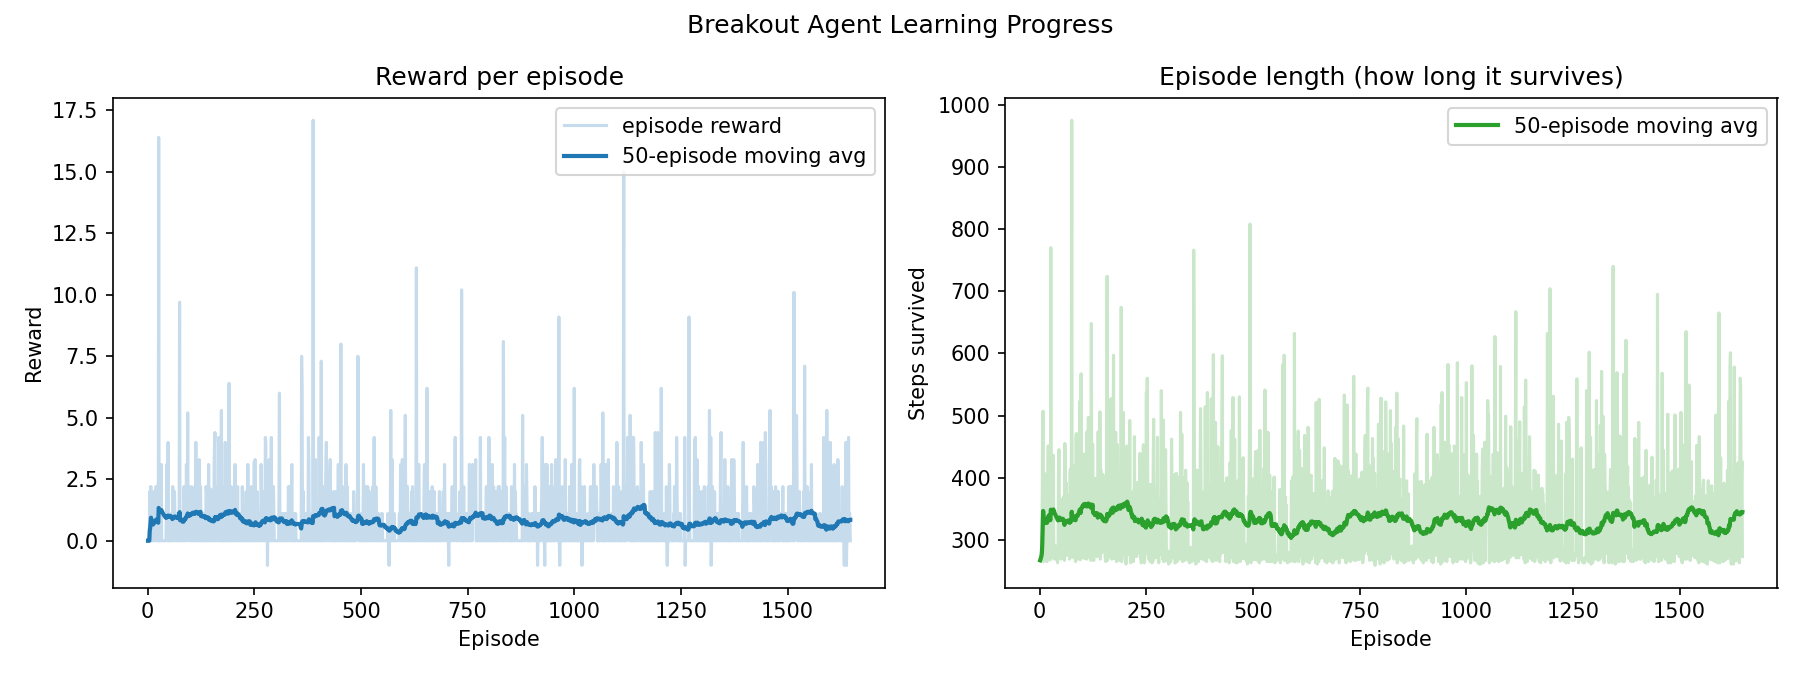

In [8]:
!python plot_progress.py
from IPython.display import Image
Image("learning_curve.png")

## 6. Watch it play inline

This records one episode as frames (headless, using `render_mode="rgb_array"`) and plays it back as an HTML5 video right in the notebook. Works the same whether you're running locally or on a remote/cloud notebook.

In [9]:
from stable_baselines3 import PPO
from watch import record_episode, show_inline

import os
model_path = "models/best_model.zip" if os.path.exists("models/best_model.zip") else "models/breakout_final.zip"
model = PPO.load(model_path)
frames, score = record_episode(model)
print(f"Episode score: {score}  |  frames: {len(frames)}")
show_inline(frames, fps=30)

Episode score: 3  |  frames: 266


## 7. (Optional) Train in stages and watch it improve

Run this pair of cells a few times in a row — each time you'll see the agent get noticeably better at clearing bricks and surviving longer.

In [15]:
!python train.py --timesteps 200000 --n-envs 8 --resume models/breakout_final.zip

Resuming from models/breakout_final.zip
Training for 200000 timesteps across 8 parallel envs...

   0% ------------------------------- 0/200,000  [ 0:00:00 < -:--:-- , ? it/s ]
   0% ----------------------------- 760/200,000  [ 0:00:00 < -:--:-- , ? it/s ]
   1% ----------------------- 1,624/200,000  [ 0:00:00 < 0:00:26 , 7,855 it/s ]
   1% ----------------------- 2,472/200,000  [ 0:00:00 < 0:00:24 , 8,433 it/s ]
   2% ----------------------- 3,352/200,000  [ 0:00:00 < 0:00:24 , 8,281 it/s ]
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 400      |
|    ep_rew_mean     | 1.32     |
| time/              |          |
|    fps             | 8296     |
|    iterations      | 1        |
|    time_elapsed    | 0        |
|    total_timesteps | 4096     |
---------------------------------
   2% ----------------------- 3,352/200,000  [ 0:00:00 < 0:00:24 , 8,281 it/s ]
   2% ----------------------- 3,352/200,000  [ 0:00:00 < 0:00:24 , 8,281 it/s ]
   

In [16]:
frames, score = record_episode(model := PPO.load("models/breakout_final.zip"))
print(f"Episode score: {score}")
show_inline(frames, fps=30)

Episode score: 4


## 8. (Optional) Live pygame window instead of inline video

Only works if this notebook is running **locally on a machine with a display attached** (won't work on Colab or a headless remote server — use the inline video above instead).

In [12]:
# !python watch.py --model models/best_model.zip --episodes 3